# Object Detection Fundamentals

**Domain:** `deep-learning`
**Level:** Intermediate
**Prerequisites:** basic Python, basic linear algebra, a first pass through
`perceptron-and-backpropagation` and `convolutional-neural-networks` (this
tutorial assumes you know what a CNN is and does not re-derive one)

## Intro: "what's in this image" vs. "what's in this image, and where"

Imagine handing someone a crowd photo and asking a single question: *"is
there at least one person in this photo?"* That's **image classification**
— one photo in, one label out. It's a yes/no (or "which one of these N
categories") judgment about the picture as a whole.

Now imagine asking a much harder question about the same photo: *"draw a
circle around every single person in this crowd, and label each one."* That's
**object detection**. It's no longer one label for the whole image — it's a
variable-length list of "here's a thing, here's exactly where it is, here's
what it is, here's how confident I am." A photo with zero people gets an
empty list; a photo with thirty people gets thirty boxes.

That difference — *localizing and counting*, not just naming — is the whole
subject of this tutorial. It's also why detection is strictly harder than
classification: the network no longer knows in advance how many objects it
will need to report, so "how where" has to be learned instead of assumed.

By the end of this tutorial you will be able to:

- Explain what a bounding box is and why detection is a fundamentally
  different (and harder) problem than classification.
- Compute **Intersection over Union (IoU)** from scratch and explain why it's
  the standard way to score "how good is this box."
- Explain **anchor boxes** — why detectors predict offsets from a fixed grid
  of reference boxes instead of predicting raw pixel coordinates.
- Implement **Non-Maximum Suppression (NMS)** from scratch and use it to
  turn a pile of overlapping raw detections into a clean final set.
- Define **mean Average Precision (mAP)**, the standard detection metric,
  precisely.
- Run a real pretrained detector (`torchvision.models.detection`) on real
  photos and draw its predictions.
- Name the real, still-debated engineering tradeoffs in detector design.


## The idea, intuitively

### A bounding box is just 4 numbers

Before any formal machinery: a **bounding box** is nothing more than four
numbers, $(x_1, y_1, x_2, y_2)$ — the pixel coordinates of the box's
top-left corner and bottom-right corner. That's it. "Detecting an object"
means producing one of these 4-number boxes (plus a class label and a
confidence score) per object found.

Let's make that concrete immediately: we'll download a real photo and draw
two bounding boxes on it by hand, using coordinates we just picked by eye.
No model, no training — just to see that a box is really just four numbers
before we build anything that predicts them automatically.


In [1]:
import io
import math
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

DATA_DIR = "_detection_data"
import os
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/pytorch/vision/main/gallery/assets/"
IMAGE_NAMES = ["dog1.jpg", "dog2.jpg", "FudanPed00054.png"]

local_paths = {}
for name in IMAGE_NAMES:
    path = os.path.join(DATA_DIR, name)
    if not os.path.exists(path):
        resp = requests.get(BASE_URL + name, timeout=30)
        resp.raise_for_status()
        with open(path, "wb") as f:
            f.write(resp.content)
    local_paths[name] = path

print("Downloaded / cached:", list(local_paths.values()))


Downloaded / cached: ['_detection_data\\dog1.jpg', '_detection_data\\dog2.jpg', '_detection_data\\FudanPed00054.png']


Image size (W, H): (500, 500)


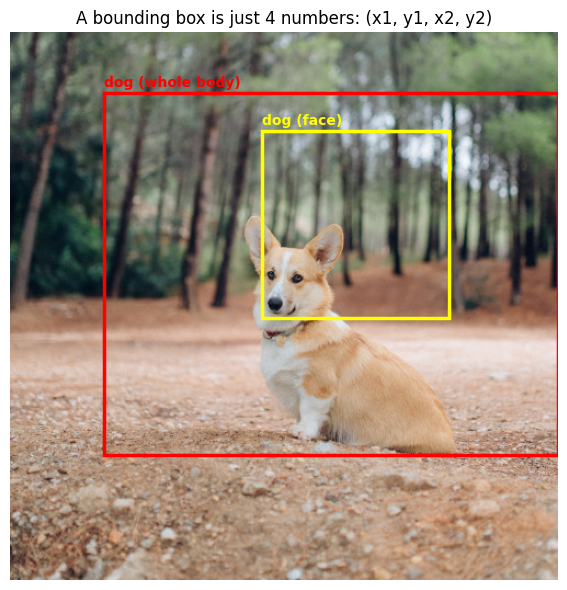

In [2]:
demo_img = Image.open(local_paths["dog1.jpg"]).convert("RGB")
demo_arr = np.array(demo_img)
print("Image size (W, H):", demo_img.size)

# Two bounding boxes, hand-picked by eye, as plain (x1, y1, x2, y2) tuples.
# Nothing fancier than "look at the picture and guess pixel coordinates."
box_dog = (85, 55, 500, 385)     # roughly around the dog
box_face = (230, 90, 400, 260)   # roughly around the dog's face

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(demo_arr)
for box, color, label in [(box_dog, "red", "dog (whole body)"),
                            (box_face, "yellow", "dog (face)")]:
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              linewidth=2.5, edgecolor=color, facecolor="none")
    ax.add_patch(rect)
    ax.text(x1, y1 - 6, label, color=color, fontsize=10, weight="bold")
ax.set_title("A bounding box is just 4 numbers: (x1, y1, x2, y2)")
ax.axis("off")
plt.tight_layout()
plt.show()


Two boxes, four numbers each, drawn on a real photo — that's the entire
output format of an object detector, before we've written a single line of
model code. Everything below is really answering three questions about
boxes like these:

1. **How do we score whether a predicted box is "close enough" to correct?**
   → Intersection over Union (IoU).
2. **How does a network even produce a *box* instead of a class label?**
   → anchor boxes.
3. **A detector proposes hundreds of overlapping boxes per object — how do
   we collapse that into one clean box per object?**
   → Non-Maximum Suppression (NMS).

**The takeaway:** classification answers "what"; detection answers "what,
where, and how many," and "where" is represented as four numbers per object.


## Going deeper: the formal definitions

### Intersection over Union (IoU)

Given two boxes $A = (x_1^A, y_1^A, x_2^A, y_2^A)$ and
$B = (x_1^B, y_1^B, x_2^B, y_2^B)$, define their **intersection** as the
rectangle formed by the overlap:

$$
x_1^I = \max(x_1^A, x_1^B), \quad y_1^I = \max(y_1^A, y_1^B), \quad
x_2^I = \min(x_2^A, x_2^B), \quad y_2^I = \min(y_2^A, y_2^B)
$$

$$
\text{Area}(I) = \max(0,\, x_2^I - x_1^I) \cdot \max(0,\, y_2^I - y_1^I)
$$

(the $\max(0, \cdot)$ guards against boxes that don't overlap at all, which
would otherwise give a negative "area"). Then **Intersection over Union**
is:

$$
\text{IoU}(A, B) = \frac{\text{Area}(A \cap B)}{\text{Area}(A \cup B)} =
\frac{\text{Area}(I)}{\text{Area}(A) + \text{Area}(B) - \text{Area}(I)}
$$

IoU is a number in $[0, 1]$: $0$ means the boxes don't touch at all, $1$
means they're identical. It's the standard way to answer "how good is this
predicted box, given the true box?" — a single scalar that penalizes both
boxes that are too small/large and boxes that are offset in the wrong
direction, unlike e.g. just comparing box centers.

### Anchor boxes: why predict *offsets*, not raw coordinates

A detector's backbone (a CNN) produces a grid of feature vectors, one per
spatial location. The naive idea would be: at each grid location, directly
predict 4 raw numbers $(x_1, y_1, x_2, y_2)$ for a box. In practice this
trains badly — raw pixel coordinates span a huge, unbounded range, objects
vary enormously in scale and aspect ratio, and the network has no prior
about what a "reasonable" box even looks like at that location.

**Anchor boxes** fix this by tiling a fixed, predefined set of reference
boxes — of various scales and aspect ratios (e.g. a small square, a wide
rectangle, a tall rectangle, at 3 scales x 3 ratios = 9 anchors) — at every
location on the feature grid, *before* any prediction happens. The network
then doesn't predict a box from scratch; it predicts small **offsets**
$(\Delta x, \Delta y, \Delta w, \Delta h)$ relative to the nearest anchor:

$$
\hat{x} = x_a + \Delta x \cdot w_a, \qquad
\hat{y} = y_a + \Delta y \cdot h_a, \qquad
\hat{w} = w_a \cdot e^{\Delta w}, \qquad
\hat{h} = h_a \cdot e^{\Delta h}
$$

where $(x_a, y_a, w_a, h_a)$ is the anchor's center and size. **Why this
helps:** the regression target is now a small, roughly-zero-centered
correction ("nudge this anchor 5% to the left and make it 10% narrower")
instead of an absolute, unbounded coordinate. Small, bounded, well-scaled
targets are exactly what gradient descent is good at fitting — this is the
same intuition as normalizing inputs before training any network, applied
to the *output* space instead. It also gives the network a natural way to
handle multiple objects at different scales/shapes at the same location:
different anchors specialize in different shapes, and each is scored
independently for "does an object look like this anchor's shape live here."

### Non-Maximum Suppression (NMS)

Because anchors tile the image densely, a real detector produces *many*
overlapping raw boxes around each true object — dozens of anchors near a
person will all fire with moderate-to-high confidence for "person here."
NMS is the standard greedy algorithm that collapses this pile into one box
per object:

1. Discard all boxes with confidence below some threshold (optional
   pre-filter).
2. Sort remaining boxes by confidence, descending.
3. Take the highest-confidence box, add it to the output ("keep" list), and
   remove it from consideration.
4. Compute IoU between that kept box and every remaining box. Discard
   (suppress) every remaining box whose IoU with it exceeds a threshold
   $\tau$ (a common default is $\tau = 0.5$) — those are judged to be
   duplicate detections of the *same* object.
5. Repeat steps 3-4 on whatever boxes remain, until none are left.

The IoU threshold $\tau$ is a real, tunable parameter, not an
implementation detail: too low and it merges genuinely separate nearby
objects into one; too high and it leaves duplicate boxes on the same
object. We implement this exact algorithm from scratch below.

### Mean Average Precision (mAP)

**mAP** is the standard metric for comparing detectors, and it's built up
in layers:

- A prediction is a **true positive** for a class if its IoU with a
  ground-truth box of that class exceeds a fixed IoU threshold (commonly
  0.5, sometimes averaged over 0.5:0.95) *and* it's the highest-confidence
  unmatched prediction for that ground-truth box; otherwise it's a **false
  positive**. Unmatched ground-truth boxes are **false negatives**.
- Precision and recall at a given confidence threshold $c$:
  $$
  \text{Precision}(c) = \frac{TP(c)}{TP(c) + FP(c)}, \qquad
  \text{Recall}(c) = \frac{TP(c)}{TP(c) + FN(c)}
  $$
- Sweeping $c$ from high to low traces out a **precision-recall curve** for
  that class. **Average Precision (AP)** for that class is the area under
  this precision-recall curve (in practice, computed via an
  interpolated/discretized sum over recall levels rather than true
  integration):
  $$
  AP = \sum_{n} (R_n - R_{n-1}) \, P_n
  $$
  where $P_n, R_n$ are the precision/recall at the $n$-th threshold, sorted
  by recall.
- **mean Average Precision (mAP)** is AP averaged across all object
  classes: $\text{mAP} = \frac{1}{K}\sum_{k=1}^{K} AP_k$ for $K$ classes.

mAP is always reported *at* a specific IoU threshold (mAP@0.5) or averaged
over a range (mAP@[0.5:0.95], the COCO-standard convention, averaging AP
over IoU thresholds 0.5, 0.55, ..., 0.95). We don't implement full mAP
computation from scratch in this tutorial (it requires a full labeled
evaluation set with ground-truth boxes matched greedily per class), but the
IoU threshold choice embedded in its definition is exactly the same
IoU-threshold idea we implement for NMS below — and, as the Limitations
section discusses, that choice materially changes the reported number.


## Visuals: IoU on two real overlapping boxes

Let's implement IoU exactly as defined above, in plain Python/numpy, and
run it on two boxes drawn over our real dog photo — then visualize the
intersection region directly.


In [3]:
def iou(box_a, box_b):
    '''Intersection over Union of two (x1, y1, x2, y2) boxes.'''
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter_w = max(0.0, ix2 - ix1)
    inter_h = max(0.0, iy2 - iy1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union_area = area_a + area_b - inter_area

    if union_area <= 0:
        return 0.0
    return inter_area / union_area


# Two real overlapping boxes on the dog photo: "whole dog" and "dog face"
# from the intro, plus a third box that overlaps the face box more tightly.
box_full = (85, 55, 500, 385)
box_face = (230, 90, 400, 260)
box_face_shifted = (260, 110, 430, 280)  # similar box, shifted

print(f"IoU(full dog, face)              = {iou(box_full, box_face):.3f}")
print(f"IoU(face, face_shifted)          = {iou(box_face, box_face_shifted):.3f}")
print(f"IoU(box, itself)                 = {iou(box_face, box_face):.3f}  (must be 1.0)")
print(f"IoU(non-overlapping boxes)       = {iou((0, 0, 10, 10), (50, 50, 60, 60)):.3f}  (must be 0.0)")


IoU(full dog, face)              = 0.211
IoU(face, face_shifted)          = 0.571
IoU(box, itself)                 = 1.000  (must be 1.0)
IoU(non-overlapping boxes)       = 0.000  (must be 0.0)


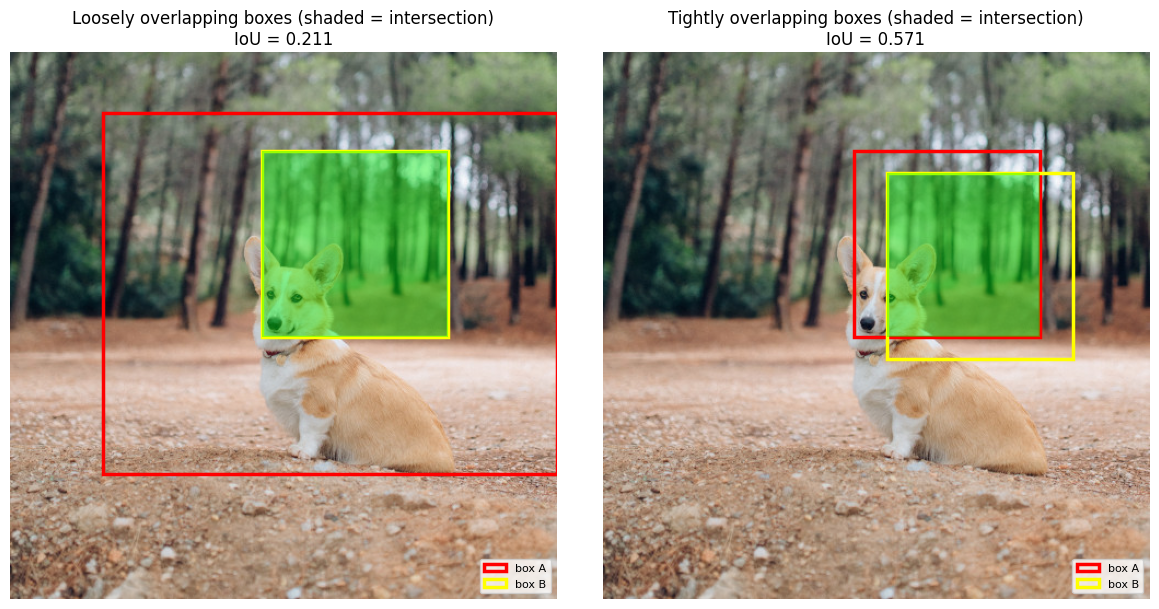

In [4]:
def draw_iou(ax, img_arr, box_a, box_b, title):
    ax.imshow(img_arr)
    x1a, y1a, x2a, y2a = box_a
    x1b, y1b, x2b, y2b = box_b

    ax.add_patch(patches.Rectangle((x1a, y1a), x2a - x1a, y2a - y1a,
                                    linewidth=2.5, edgecolor="red", facecolor="none", label="box A"))
    ax.add_patch(patches.Rectangle((x1b, y1b), x2b - x1b, y2b - y1b,
                                    linewidth=2.5, edgecolor="yellow", facecolor="none", label="box B"))

    # Shade the intersection region
    ix1, iy1 = max(x1a, x1b), max(y1a, y1b)
    ix2, iy2 = min(x2a, x2b), min(y2a, y2b)
    if ix2 > ix1 and iy2 > iy1:
        ax.add_patch(patches.Rectangle((ix1, iy1), ix2 - ix1, iy2 - iy1,
                                        facecolor="lime", alpha=0.4, edgecolor="none"))

    val = iou(box_a, box_b)
    ax.set_title(f"{title}\nIoU = {val:.3f}")
    ax.legend(loc="lower right", fontsize=8)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
draw_iou(axes[0], demo_arr, box_full, box_face, "Loosely overlapping boxes (shaded = intersection)")
draw_iou(axes[1], demo_arr, box_face, box_face_shifted, "Tightly overlapping boxes (shaded = intersection)")
plt.tight_layout()
plt.show()


The green-shaded region is exactly $\text{Area}(A \cap B)$ from the formula
above. The face-vs-shifted-face pair scores a much higher IoU than
full-dog-vs-face because a larger fraction of both boxes is shared — which
is exactly the "how close is this box to correct" signal IoU is designed to
capture.


## Non-Maximum Suppression, from scratch

Now let's implement the greedy NMS algorithm exactly as specified above,
and see it in action on a clean synthetic example first — a pile of
overlapping raw detections (the kind a dense anchor grid would actually
produce around one real object) with confidence scores, before we apply it
to a real model's output later.


In [5]:
def nms(boxes, scores, iou_threshold=0.5):
    '''Greedy Non-Maximum Suppression.

    boxes: list/array of (x1, y1, x2, y2)
    scores: list/array of confidence scores, same length as boxes
    Returns: list of indices (into the original boxes/scores) to keep.
    '''
    boxes = np.asarray(boxes, dtype=float)
    scores = np.asarray(scores, dtype=float)

    order = np.argsort(-scores)  # descending confidence
    keep = []

    while len(order) > 0:
        current = order[0]
        keep.append(int(current))
        if len(order) == 1:
            break
        rest = order[1:]
        ious = np.array([iou(boxes[current], boxes[i]) for i in rest])
        order = rest[ious <= iou_threshold]  # suppress anything above threshold

    return keep


In [6]:
# Synthetic pile of overlapping raw detections around ONE object, plus a
# second, separate object -- exactly the situation dense anchors create.
rng = np.random.default_rng(7)

def jittered_cluster(center_box, n, score_range, jitter=12):
    x1, y1, x2, y2 = center_box
    out_boxes, out_scores = [], []
    for _ in range(n):
        dx1, dy1, dx2, dy2 = rng.uniform(-jitter, jitter, size=4)
        out_boxes.append((x1 + dx1, y1 + dy1, x2 + dx2, y2 + dy2))
        out_scores.append(rng.uniform(*score_range))
    return out_boxes, out_scores

boxes_obj1, scores_obj1 = jittered_cluster((60, 50, 220, 240), n=6, score_range=(0.55, 0.97))
boxes_obj2, scores_obj2 = jittered_cluster((260, 140, 460, 380), n=5, score_range=(0.5, 0.93))

raw_boxes = boxes_obj1 + boxes_obj2
raw_scores = scores_obj1 + scores_obj2

keep_idx = nms(raw_boxes, raw_scores, iou_threshold=0.5)
print(f"Raw detections: {len(raw_boxes)}   ->   after NMS: {len(keep_idx)}")
for i in keep_idx:
    print(f"  kept box {i}: score={raw_scores[i]:.2f}  box={tuple(round(v,1) for v in raw_boxes[i])}")


Raw detections: 11   ->   after NMS: 2
  kept box 3: score=0.97  box=(np.float64(61.3), np.float64(61.9), np.float64(227.0), np.float64(242.9))
  kept box 9: score=0.87  box=(np.float64(265.8), np.float64(130.2), np.float64(461.0), np.float64(380.2))


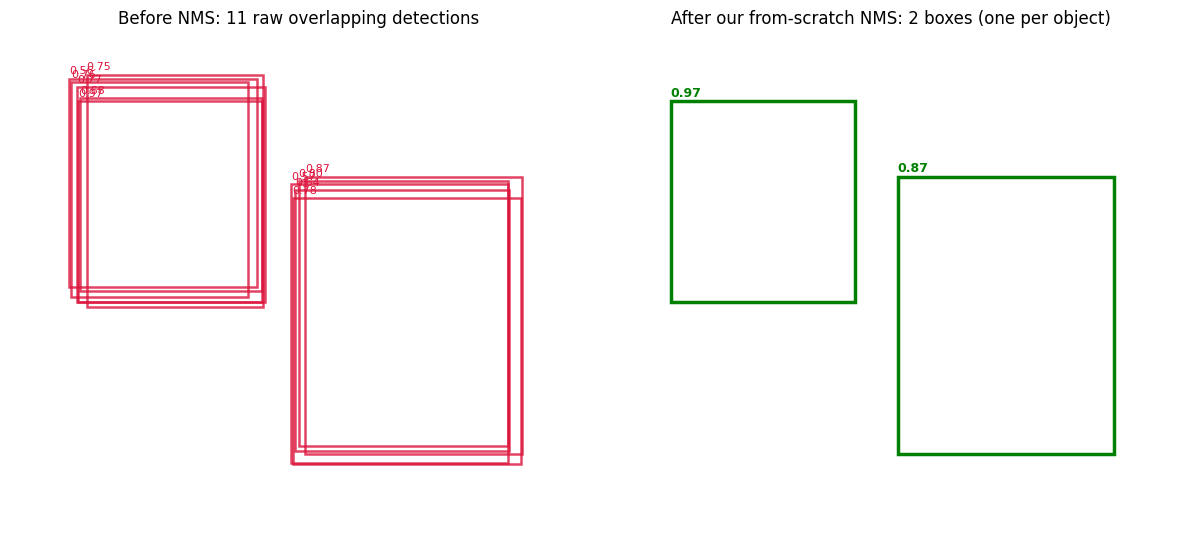

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
canvas = np.ones((450, 520, 3))  # blank canvas so overlapping boxes are easy to read

axes[0].imshow(canvas)
for box, score in zip(raw_boxes, raw_scores):
    x1, y1, x2, y2 = box
    axes[0].add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                         linewidth=1.8, edgecolor="crimson", facecolor="none", alpha=0.8))
    axes[0].text(x1, y1 - 4, f"{score:.2f}", color="crimson", fontsize=8)
axes[0].set_title(f"Before NMS: {len(raw_boxes)} raw overlapping detections")
axes[0].set_xlim(0, 520); axes[0].set_ylim(450, 0); axes[0].axis("off")

axes[1].imshow(canvas)
for i in keep_idx:
    x1, y1, x2, y2 = raw_boxes[i]
    axes[1].add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                         linewidth=2.5, edgecolor="green", facecolor="none"))
    axes[1].text(x1, y1 - 4, f"{raw_scores[i]:.2f}", color="green", fontsize=9, weight="bold")
axes[1].set_title(f"After our from-scratch NMS: {len(keep_idx)} boxes (one per object)")
axes[1].set_xlim(0, 520); axes[1].set_ylim(450, 0); axes[1].axis("off")

plt.tight_layout()
plt.show()


Six near-duplicate boxes around object 1 and five around object 2 collapse
down to exactly one highest-confidence box per object — this is precisely
what a real detector's dense anchor grid produces before NMS, and precisely
why every detector runs NMS as a final post-processing step.


## Implementation: a real pretrained detector on real photos

Now the real thing: we load a detector pretrained on **COCO**
(Common Objects in Context — 80 object categories, ~118k training images),
via `torchvision.models.detection`. We use
`fasterrcnn_mobilenet_v3_large_320_fpn` — a **two-stage** detector (Faster
R-CNN: a Region Proposal Network first proposes candidate boxes, then a
second stage classifies/refines each one) with a lightweight MobileNetV3
backbone, chosen specifically so a full forward pass runs in seconds on
CPU rather than the heavier ResNet-50 backbone.


In [8]:
import torch
import torchvision
from torchvision.models.detection import (
    fasterrcnn_mobilenet_v3_large_320_fpn,
    FasterRCNN_MobileNet_V3_Large_320_FPN_Weights,
)
from torchvision.transforms.functional import to_tensor

weights = FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT
model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=weights, box_score_thresh=0.5)
model.eval()

COCO_CATEGORIES = weights.meta["categories"]
print(f"Loaded fasterrcnn_mobilenet_v3_large_320_fpn, pretrained on COCO ({len(COCO_CATEGORIES)} categories incl. background)")
print("Sample categories:", [c for c in COCO_CATEGORIES if c not in ("N/A", "__background__")][:12])


Loaded fasterrcnn_mobilenet_v3_large_320_fpn, pretrained on COCO (91 categories incl. background)
Sample categories: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign']


`box_score_thresh=0.5` means the model already applies its own internal
post-processing (including its own NMS, at its default IoU threshold of
0.5) and only returns detections it's at least 50% confident in — this is
the normal way to use the model for a final result.


In [9]:
image_files = ["dog1.jpg", "dog2.jpg", "FudanPed00054.png"]
pil_images = [Image.open(local_paths[f]).convert("RGB") for f in image_files]
tensors = [to_tensor(img) for img in pil_images]

with torch.no_grad():
    predictions = model(tensors)

for fname, pred in zip(image_files, predictions):
    print(f"{fname}: {len(pred['boxes'])} final detections at score > 0.5")


dog1.jpg: 1 final detections at score > 0.5
dog2.jpg: 1 final detections at score > 0.5
FudanPed00054.png: 4 final detections at score > 0.5


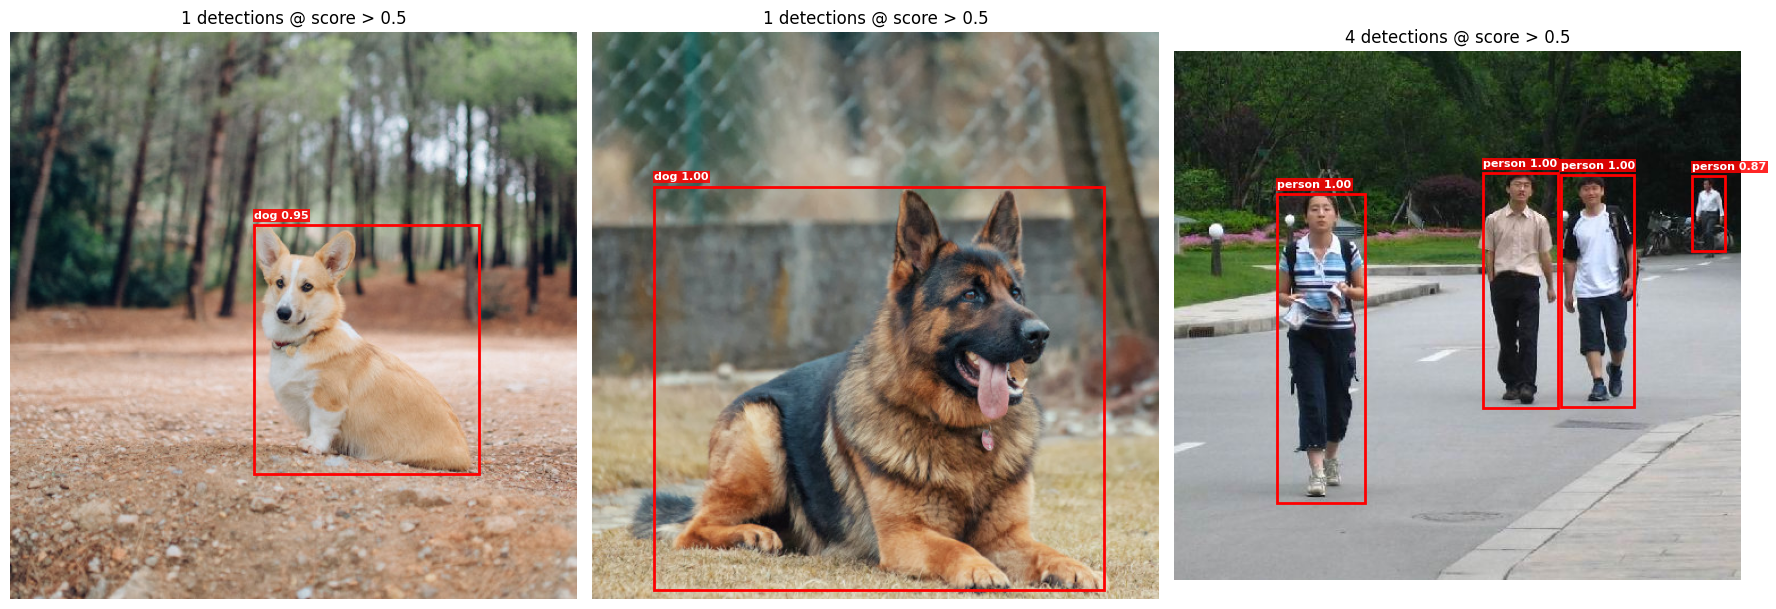

In [10]:
def draw_detections(ax, pil_img, boxes, labels, scores, categories, score_thresh=0.5, box_color="red"):
    ax.imshow(np.array(pil_img))
    n_drawn = 0
    for box, label, score in zip(boxes, labels, scores):
        if score < score_thresh:
            continue
        x1, y1, x2, y2 = box
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                        linewidth=2, edgecolor=box_color, facecolor="none"))
        cat_name = categories[label]
        ax.text(x1, max(0, y1 - 6), f"{cat_name} {score:.2f}",
                color="white", fontsize=8, weight="bold",
                bbox=dict(facecolor=box_color, alpha=0.85, pad=1, edgecolor="none"))
        n_drawn += 1
    ax.set_title(f"{n_drawn} detections @ score > {score_thresh}")
    ax.axis("off")


fig, axes = plt.subplots(1, len(image_files), figsize=(6 * len(image_files), 6))
for ax, fname, img, pred in zip(axes, image_files, pil_images, predictions):
    boxes = pred["boxes"].detach().numpy()
    labels = pred["labels"].detach().numpy()
    scores = pred["scores"].detach().numpy()
    draw_detections(ax, img, boxes, labels, scores, COCO_CATEGORIES, score_thresh=0.5)
plt.tight_layout()
plt.show()


Those are real predicted boxes, real COCO class labels, and real confidence
scores from a real forward pass through a pretrained network — nothing
here is hand-placed.

### Applying our from-scratch NMS to the model's genuinely raw, pre-NMS output

The figure above already had the model's *own* internal NMS applied. To
actually exercise our own `nms` function on real raw proposals, we need
real *pre*-suppression output — so we load a second copy of the same
model with its internal suppression effectively disabled
(`box_nms_thresh=1.0`, i.e. never suppress) and a low confidence floor
(`box_score_thresh=0.05`), which forces it to hand back every
still-plausible candidate box, duplicates and all — exactly the dense,
overlapping-anchor situation our synthetic NMS demo simulated earlier.


In [11]:
raw_model = fasterrcnn_mobilenet_v3_large_320_fpn(
    weights=weights, box_score_thresh=0.05, box_nms_thresh=1.0, box_detections_per_img=300,
)
raw_model.eval()

pick_idx = 2  # FudanPed00054.png: several real people close together --
              # the clearest real example of overlapping raw person detections
fname = image_files[pick_idx]

with torch.no_grad():
    raw_pred = raw_model([tensors[pick_idx]])[0]

boxes_np = raw_pred["boxes"].detach().numpy()
labels_np = raw_pred["labels"].detach().numpy()
scores_np = raw_pred["scores"].detach().numpy()
print(f"{fname}: {len(boxes_np)} genuinely pre-NMS raw candidate boxes (internal NMS disabled)")

# Light confidence pre-filter (step 1 of the NMS procedure above)
conf_thresh = 0.3
mask = scores_np > conf_thresh
boxes_f, labels_f, scores_f = boxes_np[mask], labels_np[mask], scores_np[mask]
print(f"-> {len(boxes_f)} boxes remain above confidence {conf_thresh}")

# Run OUR from-scratch NMS, per class (never suppress a "dog" box because
# it overlaps a "cat" box -- NMS is applied within each class independently)
final_keep = []
for cls in np.unique(labels_f):
    cls_mask = labels_f == cls
    cls_idx = np.nonzero(cls_mask)[0]
    kept_local = nms(boxes_f[cls_idx], scores_f[cls_idx], iou_threshold=0.5)
    final_keep.extend(cls_idx[kept_local].tolist())

print(f"After our from-scratch per-class NMS: {len(final_keep)} boxes kept")
for i in final_keep:
    print(f"  {COCO_CATEGORIES[labels_f[i]]}: score={scores_f[i]:.2f}  box={tuple(round(v,1) for v in boxes_f[i])}")


FudanPed00054.png: 44 genuinely pre-NMS raw candidate boxes (internal NMS disabled)
-> 30 boxes remain above confidence 0.3
After our from-scratch per-class NMS: 4 boxes kept
  person: score=1.00  box=(np.float32(362.9), np.float32(116.1), np.float32(432.3), np.float32(334.2))
  person: score=1.00  box=(np.float32(96.8), np.float32(134.0), np.float32(179.2), np.float32(424.4))
  person: score=1.00  box=(np.float32(290.3), np.float32(115.0), np.float32(361.0), np.float32(335.6))
  person: score=0.87  box=(np.float32(486.8), np.float32(117.8), np.float32(517.5), np.float32(187.5))


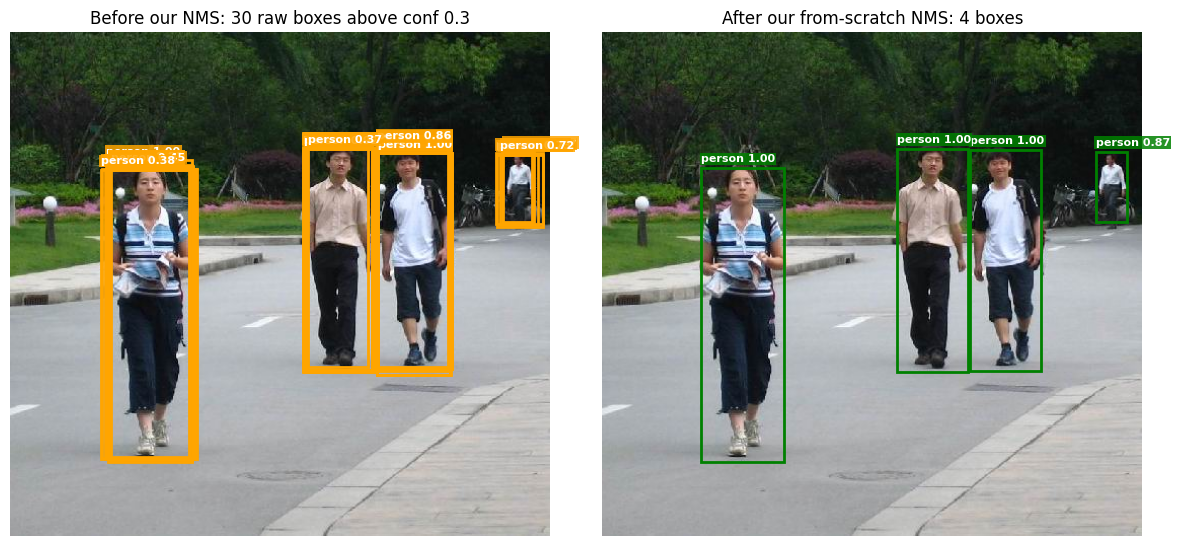

For comparison, the standard model (its own internal NMS @ 0.5, score > 0.5) kept 4 boxes on this same image.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

draw_detections(axes[0], pil_images[pick_idx], boxes_f, labels_f, scores_f,
                 COCO_CATEGORIES, score_thresh=conf_thresh, box_color="orange")
axes[0].set_title(f"Before our NMS: {len(boxes_f)} raw boxes above conf {conf_thresh}")

kept_boxes = boxes_f[final_keep]
kept_labels = labels_f[final_keep]
kept_scores = scores_f[final_keep]
draw_detections(axes[1], pil_images[pick_idx], kept_boxes, kept_labels, kept_scores,
                 COCO_CATEGORIES, score_thresh=0.0, box_color="green")
axes[1].set_title(f"After our from-scratch NMS: {len(final_keep)} boxes")

plt.tight_layout()
plt.show()

n_standard = len(predictions[pick_idx]["boxes"])
print(f"For comparison, the standard model (its own internal NMS @ 0.5, score > 0.5) "
      f"kept {n_standard} boxes on this same image.")


Our from-scratch NMS, run on genuinely pre-suppression raw proposals,
collapses dozens of near-duplicate overlapping boxes down to a handful —
landing on essentially the same count the model's own internal NMS
produced in the very first detection figure above. That confirms the
algorithm we derived and coded from scratch (sort by confidence, keep the
top box, suppress overlapping boxes above the IoU threshold, repeat) really
does match what a production detector's built-in post-processing does
internally, on real raw model output, not just on the clean synthetic
example from before.


## Use cases

Object detection is one of the most directly deployed computer vision
techniques, precisely because so many real problems need "where" and "how
many," not just "what":

- **Autonomous driving perception**: detecting and localizing other
  vehicles, pedestrians, cyclists, and traffic signs in real time is a
  core input to planning/control — a missed detection or a badly-localized
  box has direct safety consequences, which is why AV perception stacks
  are held to far stricter recall/latency requirements than a typical
  photo-tagging application.
- **Retail and inventory counting**: counting products on a shelf, or
  detecting empty shelf space, from store-camera or drone imagery —
  detection's "how many, and where" is exactly the signal needed, not just
  "is there a product visible."
- **Medical imaging localization**: localizing tumors, lesions, or other
  findings in radiology images (e.g. detecting nodules in chest CT scans)
  so a clinician's attention is directed to the right region, not just told
  "abnormal image found."
- **Surveillance and security**: detecting and counting people or vehicles
  in camera feeds. This use case carries real responsible-use
  considerations — bias in who gets detected/misdetected across
  demographics, and the privacy implications of automated tracking at
  scale — that this tutorial doesn't cover in depth; see this repo's
  `responsible-data-science` domain for a dedicated treatment of fairness
  and privacy in deployed ML systems.
- **Robotics**: a robot arm or mobile robot needs to localize objects
  in its workspace (a part on a conveyor belt, an obstacle in a hallway)
  before it can act on or navigate around them — detection is usually the
  first stage of a robotic perception pipeline, feeding into grasping or
  path planning.


## Limitations & debates

- **The confidence-threshold tradeoff is real and practitioner-tuned, not
  automatic.** Lowering the confidence threshold recovers more true
  positives (higher recall) but also lets in more false positives (lower
  precision) — there is no threshold that is simultaneously optimal for
  every deployment. An autonomous-driving stack tuned to minimize missed
  pedestrians will accept more false alarms than a retail shelf-counting
  system would tolerate; the "right" threshold is a deployment-specific
  business/safety decision, not a property of the model.
- **The IoU threshold is not a free parameter — it changes the reported
  score.** The same detector, evaluated with mAP@0.5 vs. mAP@0.75, produces
  materially different numbers, and NMS run with $\tau=0.3$ vs. $\tau=0.7$
  produces different final box sets on the same raw output. This is a real,
  documented source of benchmark inconsistency between papers that quietly
  differ in which IoU convention they report — always check *which*
  IoU threshold a claimed mAP number uses before comparing across papers.
- **Small-object detection is a well-documented hard case.** Anchor boxes
  are tiled at fixed scales relative to the feature map's resolution; a
  small object can fail to align well with any anchor's scale/aspect
  ratio, and after several downsampling (pooling/stride) layers in the
  backbone, small objects can shrink to a handful of feature-map pixels or
  vanish from the feature map entirely — a documented failure mode
  motivating techniques like Feature Pyramid Networks (multi-scale feature
  maps, used in the FPN backbone in this tutorial's own model) and
  higher-resolution input crops specifically for small-object-heavy tasks
  like aerial/satellite imagery.
- **Two-stage vs. one-stage detectors: a real, ongoing speed/accuracy
  tradeoff, not a solved question.** Two-stage detectors (Faster R-CNN,
  used in this tutorial: a Region Proposal Network proposes candidate
  boxes, then a second stage classifies and refines each one) historically
  achieve higher accuracy at the cost of speed. One-stage detectors
  (YOLO, SSD: predict boxes and classes directly from the feature grid in
  a single pass, no separate proposal stage) trade some accuracy for
  substantially faster inference, which matters directly for real-time
  applications like autonomous driving or live video. Modern one-stage
  detectors (later YOLO versions) have closed much of that historical
  accuracy gap, but the underlying architectural tradeoff — a dedicated
  proposal stage costs latency but can afford more careful refinement — is
  still the reason both design families remain actively used and developed
  rather than one having fully displaced the other.
- **NMS itself has known failure modes.** Greedy NMS can incorrectly
  suppress a correct detection of a second, genuinely separate object that
  happens to heavily overlap a higher-confidence detection (e.g. two people
  standing close together) — this is a specific, named limitation of hard
  greedy suppression, and is the motivation behind alternatives like
  Soft-NMS (down-weight instead of discard overlapping boxes) that this
  tutorial doesn't implement but is worth knowing exists.


## References

- Ren, S., He, K., Girshick, R., & Sun, J. (2015). *Faster R-CNN: Towards
  Real-Time Object Detection with Region Proposal Networks.* NeurIPS.
  The two-stage detector architecture used in this tutorial's implementation.
- Redmon, J., Divvala, S., Girshick, R., & Farhadi, A. (2016). *You Only
  Look Once: Unified, Real-Time Object Detection.* CVPR. The original
  one-stage (YOLO) detector.
- Liu, W. et al. (2016). *SSD: Single Shot MultiBox Detector.* ECCV.
- Lin, T.-Y. et al. (2014). *Microsoft COCO: Common Objects in Context.*
  ECCV. The dataset/category set and mAP@[0.5:0.95] evaluation convention
  used throughout this tutorial.
- Lin, T.-Y. et al. (2017). *Feature Pyramid Networks for Object
  Detection.* CVPR — the multi-scale FPN backbone referenced in the
  small-object-detection discussion above.
- Bodla, N., Singh, B., Chellappa, R., & Davis, L. S. (2017). *Soft-NMS —
  Improving Object Detection With One Line of Code.* ICCV.
- Girshick, R. (2015). *Fast R-CNN.* ICCV. Precursor to Faster R-CNN.
- `torchvision.models.detection` documentation,
  [pytorch.org/vision/stable/models.html#object-detection](https://pytorch.org/vision/stable/models.html#object-detection)
  — pretrained COCO detectors used in this tutorial's implementation.
- Sample images: `pytorch/vision` gallery assets,
  [github.com/pytorch/vision/tree/main/gallery/assets](https://github.com/pytorch/vision/tree/main/gallery/assets)
